# H-alpha high-contrast imaging with the WCC vs pointing jitter, Strehl ratio and PSF stability

**Question.** `halpha_hci_feasibility.ipynb` finds that PDS 70 b and c are detectable in the 2 nm H-alpha
filter within an hour *at the photon limit with an ideal PSF subtraction*. How does that hold up if the
delivered jitter is 0-20 mas (1σ per axis) and the Strehl ratio 1.0-0.7, and what does the PSF's
*stability* between science and reference frames cost?

**Three effects, treated separately.**
1. **Static PSF shape.** Jitter smears the Airy rings and wavefront error puts light into the 100-300 mas
   zone. Both change the stellar light in the planet aperture and so the photon-noise limit, and both lower
   the peak pixel and lengthen the saturation-limited frame.
2. **Symmetric subtraction residuals.** If science and reference differ in jitter or in the amount of
   symmetric halo, the residual is azimuthally symmetric. A radial-profile fit (or a reference scaled in an
   annulus around the planet, standard practice) removes it. These are shown once, before and after that
   subtraction, to establish that they are *not* the floor.
3. **Asymmetric residuals (speckles): the real floor.** A change of the wavefront between science and
   reference by a few nm RMS produces speckles that interfere with the Airy rings and the static
   aberration pattern. They are not symmetric and survive a radial fit. A registration error between science
   and reference does the same (a dipole). These are computed with a pupil-plane model
   (`hci_psf.WfePSF`: unobscured circular pupil, phase screen, FFT onto the same fine grid as the ETC
   Airy), and quoted after the radial-profile subtraction.

Floors are expressed as a planet/star flux ratio: planet flux = **5 x the RMS residual** in a 2 px aperture
over 24 position angles and one Airy FWHM of separation, divided by the planet's enclosed fraction. The
factor 5 is a *bias margin* on a deterministic residual, not a 5σ statistic; it does not average down with
exposure time the way the photon term does. Divide by 5 for the raw residual.

Host: PDS 70 (K7V, Gaia G = 11.6). Strehl values are at 656 nm; the requirement ($S = 0.8$ at r, 615 nm)
is $S = 0.82$ at H-alpha and is one of the grid values, so the requirement box on the heatmaps is exact.
Baseline for ratios: 10 mas, $S = 1$. PDS 70 b is placed at 160 mas (its 2023-2024 separation; Close et al.
2025), c at 210 mas.

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

plt.style.use('gks')
warnings.filterwarnings('ignore')

from hci_psf import (Instrument, WfePSF, contrast_curve, aperture_fractions, speckle_floor, shifted, strehl_at,
                     wfe_from_strehl, HALO_K, OVERSAMPLE)

JITTERS = np.arange(0.0, 20.01, 2.5)
S_REQ = float(strehl_at(0.8, 656.3))                # S = 0.8 at r  ->  0.822 at H-alpha
STREHLS = np.array([1.0, 0.9, round(S_REQ, 3), 0.7])   # at 656 nm
SEPS_KEY = [100.0, 160.0, 300.0]
REQ_JIT = 10.0
FILTERS = ['zwo:halpha2', 'zwo:halpha6', 'zwo:halpha20']
FLAB = {'zwo:halpha2': 'H-alpha 2 nm', 'zwo:halpha6': 'H-alpha 6 nm', 'zwo:halpha20': 'H-alpha 20 nm'}
TEAL, RED, AMBER, BLUE, GREEN, DBLUE = '#00798c', '#d1495b', '#edae49', '#30638e', '#66a182', '#003d5b'
SCOL = dict(zip(STREHLS, [TEAL, GREEN, AMBER, RED]))
HOST_SPT, HOST_G = 'K7V', 11.6
PLANETS = {'b': dict(sep_mas=160.0, flux=8.1e-16), 'c': dict(sep_mas=210.0, flux=3.1e-16)}
T_TOT = 3600.0
R_AP = 2.0                                          # px; the optimiser's choice at 160 mas in the feasibility notebook
DRIFT_NM = 2.8                                      # reference drift level [nm RMS]; floors scale linearly with it
N_REAL = 3                                          # random wavefront realisations averaged
OUT = 'halpha_hci_out'
os.makedirs(OUT, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(OUT, name + '.png'), dpi=200)
    fig.savefig(os.path.join(OUT, name + '.pdf'))

def req_lines(ax, jitter=True, strehl=False):
    if jitter: ax.axvline(REQ_JIT, color='0.4', ls='--', lw=1, label='requirement')
    if strehl: ax.axvline(S_REQ, color='0.4', ls='--', lw=1, label='requirement (S = 0.8 at r)')

INST = {f: Instrument(f, HOST_SPT, HOST_G) for f in FILTERS}
inst = INST['zwo:halpha2']
RATIO = {(f, p): INST[f].line_rate(pl['flux']) / INST[f].star_rate for f in FILTERS for p, pl in PLANETS.items()}
RB = RATIO['zwo:halpha2', 'b']
print('Strehl at 656 nm -> at 615 nm (same WFE):', {float(s): round(float(strehl_at(s, 615.0, 656.3)), 3) for s in STREHLS})
print('implied RMS WFE [nm] at 656 nm:', {float(s): round(float(wfe_from_strehl(s, 656.3)), 1) for s in STREHLS if s < 1})
print('PDS 70 planet/star ratio per filter:', {f'{FLAB[f]} {p}': f'{v:.2e}' for (f, p), v in RATIO.items()})

Strehl at 656 nm -> at 615 nm (same WFE): {1.0: 1.0, 0.9: 0.887, 0.822: 0.8, 0.7: 0.666}
implied RMS WFE [nm] at 656 nm: {0.9: 33.9, 0.822: 46.2, 0.7: 62.4}
PDS 70 planet/star ratio per filter: {'H-alpha 2 nm b': '5.73e-04', 'H-alpha 2 nm c': '2.19e-04', 'H-alpha 6 nm b': '1.86e-04', 'H-alpha 6 nm c': '7.13e-05', 'H-alpha 20 nm b': '5.71e-05', 'H-alpha 20 nm c': '2.19e-05'}


## 1. What jitter and Strehl do to the stellar light at the planet's separation

Two PSF models are compared here: the core + Gaussian-halo model of the companion jitter/Strehl study
(`StrehlPSF`, halo FWHM $k = 4$ Airy FWHM) and a pupil-plane model with a random static wavefront of
power-law PSD ($\propto f^{-2.5}$, 1 cycle/D to Nyquist) scaled to the same Strehl. The second is closer to
polished optics and is the one used for the speckle floors below; the first is kept for the static grid
because it is the model the requirement discussion has used so far, and the comparison calibrates it.

static screens: S -> {1.0: '0.0 nm, S_check 1.000', 0.9: '34.1 nm, S_check 0.900', 0.822: '46.2 nm, S_check 0.822', 0.7: '62.3 nm, S_check 0.700'}



stellar light in a 2 px aperture at 160 mas, relative to (10 mas, S = 1, Airy):


strehl gauss_k2 gauss_k4 gauss_k8 powerlaw_wfe peak_fraction t_frame_s
------ -------- -------- -------- ------------ ------------- ---------
   1.0     1.00     1.00     1.00         1.00          0.09      7.57
   0.9     0.92     1.81     1.96         1.56          0.08      8.33
 0.822     0.86     2.44     2.71         1.62          0.07      9.04
   0.7     0.77     3.43     3.88         2.55          0.06     10.43
  jitter  0 mas, S = 1: x0.89, peak fraction 0.109, frame time 6.1 s
  jitter 20 mas, S = 1: x1.11, peak fraction 0.053, frame time 12.4 s


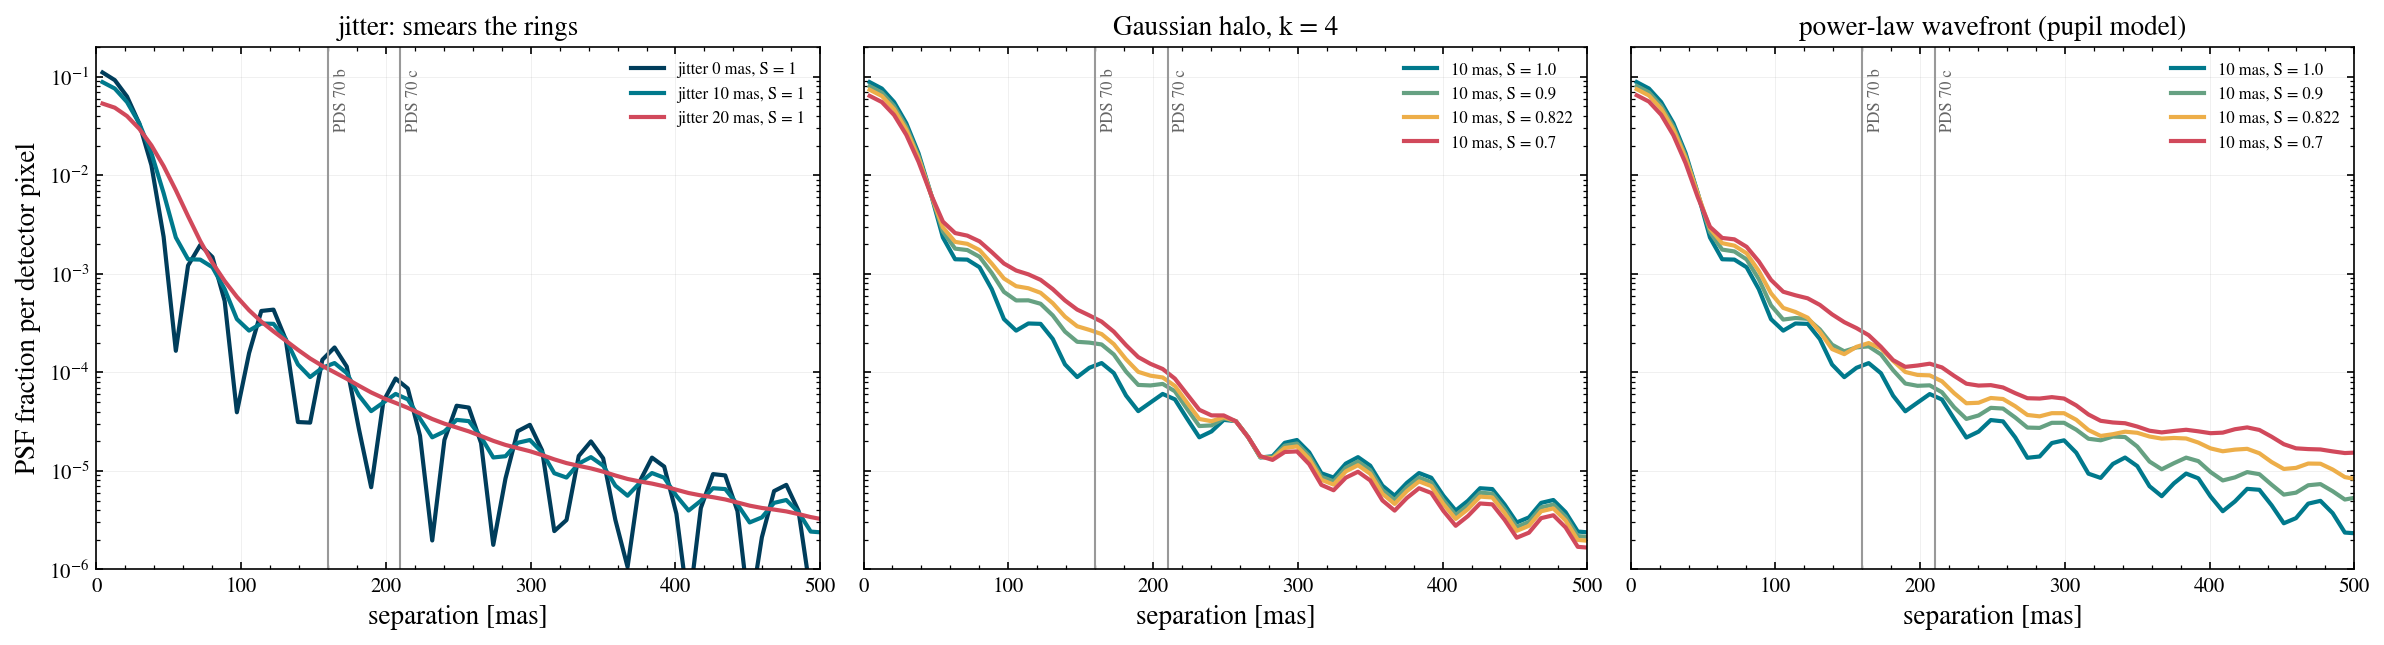

In [2]:
def radial_profile_px(psf_fine, plate_mas, dr_px=0.5):
    n = psf_fine.shape[0]; c = (n - 1) / 2
    yy, xx = np.mgrid[:n, :n]
    r = np.hypot(xx - c, yy - c) / OVERSAMPLE
    edges = np.arange(0, r.max(), dr_px)
    idx = np.digitize(r.ravel(), edges) - 1
    p = psf_fine.ravel() * OVERSAMPLE ** 2
    prof = np.bincount(idx, weights=p, minlength=edges.size) / np.maximum(np.bincount(idx, minlength=edges.size), 1)
    return (edges[:-1] + dr_px / 2) * plate_mas, prof[:-1]

W = WfePSF(inst, seed=1)
FLAT = np.zeros((W.n_pup, W.n_pup))
STATIC = {float(s): (FLAT if s >= 1 else W.screen_for_strehl(float(s))) for s in STREHLS}
print('static screens: S ->', {s: f'{W.rms_nm(sc):.1f} nm, S_check {W.strehl(sc):.3f}' for s, sc in STATIC.items()})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for j, col in zip([0.0, 10.0, 20.0], [DBLUE, TEAL, RED]):
    r, p = radial_profile_px(inst.fine_psf(j, 1.0), inst.plate_mas)
    axes[0].plot(r, p, color=col, label=f'jitter {j:.0f} mas, S = 1')
for s in STREHLS:
    r, p = radial_profile_px(inst.fine_psf(REQ_JIT, float(s)), inst.plate_mas)
    axes[1].plot(r, p, color=SCOL[s], label=f'10 mas, S = {s}')
    r, p = radial_profile_px(W.psf(STATIC[float(s)], REQ_JIT), inst.plate_mas)
    axes[2].plot(r, p, color=SCOL[s], label=f'10 mas, S = {s}')
for ax in axes:
    for name, pl in PLANETS.items():
        ax.axvline(pl['sep_mas'], color='0.6', lw=1); ax.text(pl['sep_mas'] + 4, 3e-2, f'PDS 70 {name}', fontsize=8, rotation=90, color='0.4')
    ax.set_yscale('log'); ax.set_ylim(1e-6, 0.2); ax.set_xlim(0, 500); ax.set_xlabel('separation [mas]'); ax.legend(fontsize=8)
axes[0].set_ylabel('PSF fraction per detector pixel')
axes[0].set_title('jitter: smears the rings'); axes[1].set_title(f'Gaussian halo, k = {HALO_K:.0f}'); axes[2].set_title('power-law wavefront (pupil model)')
fig.tight_layout(); savefig(fig, 'fig06_js_profiles')

print(f'\nstellar light in a {R_AP:.0f} px aperture at 160 mas, relative to (10 mas, S = 1, Airy):')
s0, _ = aperture_fractions(inst, inst.fine_psf(REQ_JIT, 1.0), [160.0], R_AP)
rows = []
for s in STREHLS:
    s = float(s)
    g4, _ = aperture_fractions(inst, inst.fine_psf(REQ_JIT, s), [160.0], R_AP)
    g2, _ = aperture_fractions(inst, inst.fine_psf(REQ_JIT, s, halo_k=2.0), [160.0], R_AP)
    g8, _ = aperture_fractions(inst, inst.fine_psf(REQ_JIT, s, halo_k=8.0), [160.0], R_AP)
    pw, _ = aperture_fractions(inst, W.psf(STATIC[s], REQ_JIT), [160.0], R_AP)
    rows.append(dict(strehl=s, gauss_k2=g2[0] / s0[0], gauss_k4=g4[0] / s0[0], gauss_k8=g8[0] / s0[0], powerlaw_wfe=pw[0] / s0[0],
                     peak_fraction=inst.peak_fraction(REQ_JIT, s), t_frame_s=inst.frame_time(REQ_JIT, s)))
CAL = Table(rows)
for c in ['gauss_k2', 'gauss_k4', 'gauss_k8', 'powerlaw_wfe', 'peak_fraction', 't_frame_s']: CAL[c].format = '%.2f'
CAL.write(os.path.join(OUT, 'js_static_model_calibration.ecsv'), format='ascii.ecsv', overwrite=True)
CAL.pprint()
for j in [0, 20]:
    sf, _ = aperture_fractions(inst, inst.fine_psf(j, 1.0), [160.0], R_AP)
    print(f'  jitter {j:2d} mas, S = 1: x{sf[0] / s0[0]:.2f}, peak fraction {inst.peak_fraction(j, 1.0):.3f}, frame time {inst.frame_time(j, 1.0):.1f} s')

The Gaussian halo with $k = 4$ puts more light at 160 mas than a power-law wavefront of the same Strehl
(table above): it is conservative in stellar light at $S = 0.82$, and the power-law result sits between the
$k = 2$ and $k = 4$ Gaussians. The static grid below therefore overstates the Strehl penalty somewhat; the
speckle floors use the pupil model directly.

## 2. Static effect: the photon-noise limit across the grid

5σ line-flux limit in 1 h (ideal subtraction) at 100, 160 and 300 mas, 2 nm filter, PDS 70 host, Gaussian-halo
model. The aperture is re-optimised at every grid point.

36 grid points in 10 s


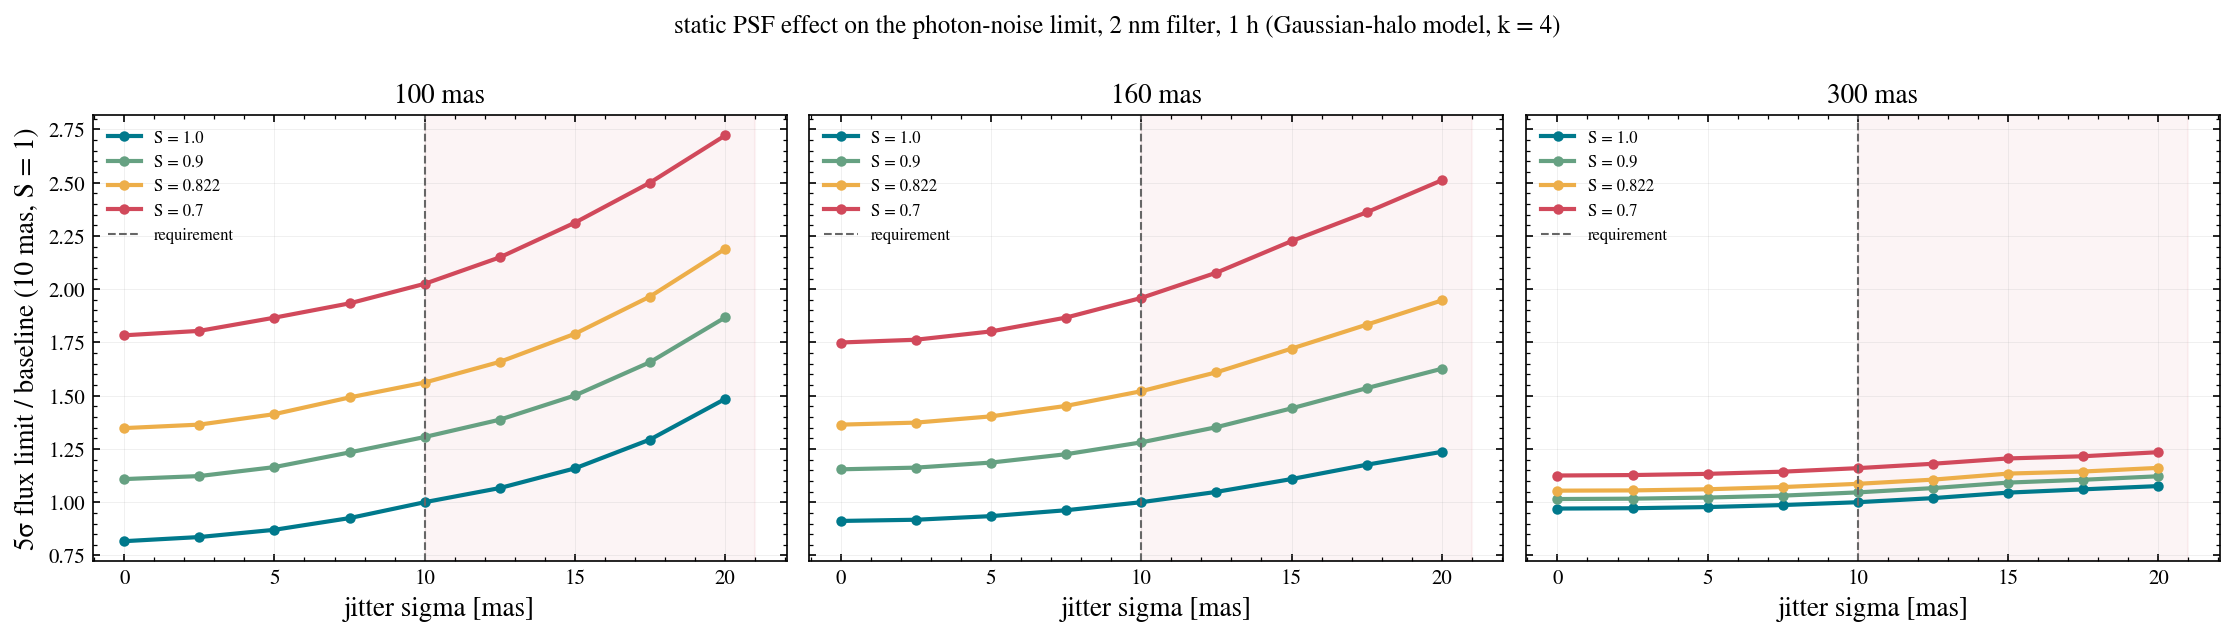

In [3]:
t0 = time.time()
rows = []
LIM = np.empty((JITTERS.size, STREHLS.size, len(SEPS_KEY)))
per_1e16 = inst.line_rate(1e-16) / inst.star_rate
for i, j in enumerate(JITTERS):
    for k, s in enumerate(STREHLS):
        cc = contrast_curve(inst, j, float(s), SEPS_KEY, T_TOT)
        LIM[i, k] = cc['contrast'] / per_1e16 * 1e-16
        for m, sep in enumerate(SEPS_KEY):
            rows.append(dict(jitter=j, strehl=float(s), sep_mas=sep, flux_lim_5sig_1h=LIM[i, k, m], r_ap_px=cc['r_ap_px'][m],
                             t_frame_s=cc['t_frame_s'], n_frames=cc['n_frames']))
STATIC_T = Table(rows); STATIC_T['flux_lim_5sig_1h'].format = '%.3e'
STATIC_T.write(os.path.join(OUT, 'js_static_fluxlimit.ecsv'), format='ascii.ecsv', overwrite=True)
iJ0, iS0 = int(np.flatnonzero(JITTERS == REQ_JIT)[0]), 0
iSR = int(np.argmin(np.abs(STREHLS - S_REQ)))
print(f'{JITTERS.size * STREHLS.size} grid points in {time.time() - t0:.0f} s')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (m, sep) in zip(axes, enumerate(SEPS_KEY)):
    for k, s in enumerate(STREHLS):
        ax.plot(JITTERS, LIM[:, k, m] / LIM[iJ0, iS0, m], 'o-', ms=4, color=SCOL[s], label=f'S = {s}')
    req_lines(ax); ax.axvspan(REQ_JIT, 21, color=RED, alpha=0.06)
    ax.set_xlabel('jitter sigma [mas]'); ax.set_title(f'{sep:.0f} mas'); ax.legend(fontsize=8)
axes[0].set_ylabel('5σ flux limit / baseline (10 mas, S = 1)')
fig.suptitle('static PSF effect on the photon-noise limit, 2 nm filter, 1 h (Gaussian-halo model, k = 4)', y=1.0)
fig.tight_layout(); savefig(fig, 'fig07_js_static_ratio')

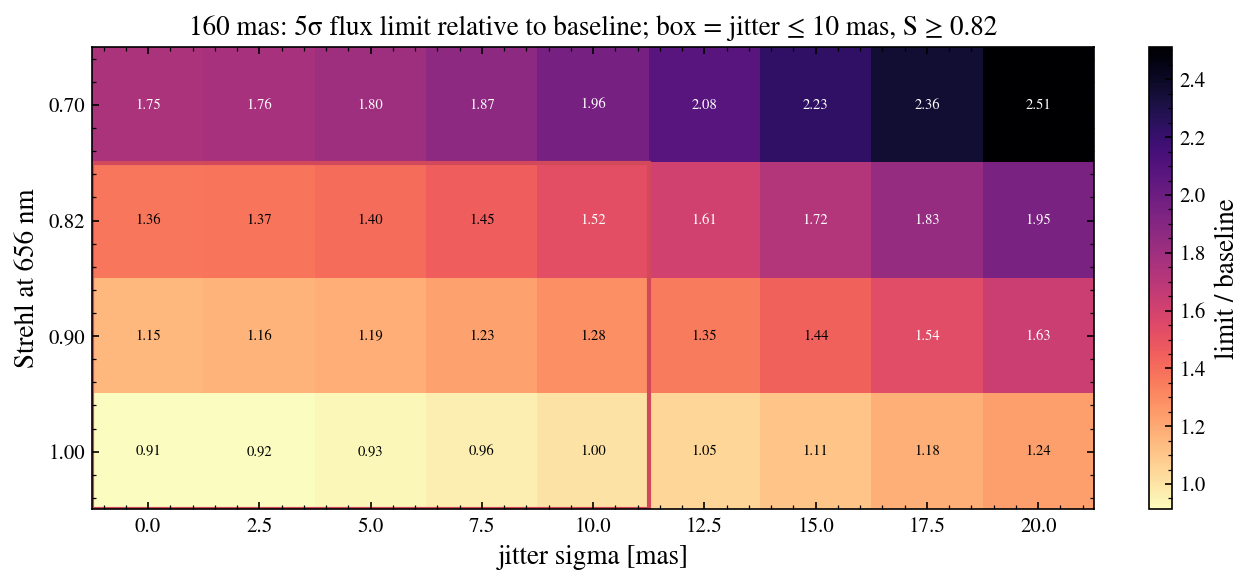

In [4]:
def heatmap(ax, Z, title, fmt='{:.2f}', cmap='magma_r', cbar_label='', vmin=None, vmax=None):
    n_j0 = int(np.sum(JITTERS <= REQ_JIT)); n_s8 = int(np.sum(STREHLS >= S_REQ - 1e-3))
    im = ax.imshow(Z.T, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[-0.5, JITTERS.size - 0.5, -0.5, STREHLS.size - 0.5])
    ax.set_xticks(range(JITTERS.size)); ax.set_xticklabels([f'{j:.1f}' for j in JITTERS])
    ax.set_yticks(range(STREHLS.size)); ax.set_yticklabels([f'{s:.2f}' for s in STREHLS])
    ax.set_xlabel('jitter sigma [mas]'); ax.set_ylabel('Strehl at 656 nm'); ax.set_title(title)
    for i in range(JITTERS.size):
        for k in range(STREHLS.size):
            rgb = im.cmap(im.norm(Z[i, k]))[:3]; lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
            ax.text(i, k, fmt.format(Z[i, k]), ha='center', va='center', fontsize=7, color='w' if lum < 0.5 else 'k')
    ax.add_patch(plt.Rectangle((-0.5, -0.5), n_j0, n_s8, fill=False, ec=RED, lw=2))
    ax.grid(False); plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046)

fig, ax = plt.subplots(figsize=(8.5, 4))
heatmap(ax, LIM[:, :, 1] / LIM[iJ0, iS0, 1], '160 mas: 5σ flux limit relative to baseline; box = jitter ≤ 10 mas, S ≥ 0.82',
        cbar_label='limit / baseline')
fig.tight_layout(); savefig(fig, 'fig08_js_static_heatmap')

## 3. Subtraction residuals

### 3.1 Symmetric residuals are removed by a radial-profile fit

Jitter that differs by 20% between science and reference, or a Strehl halo that differs by $\Delta S = 0.02$
(Gaussian model), leaves an azimuthally symmetric residual. Below: that residual as a floor, before and after
subtracting its azimuthal mean (what a radial-profile fit or annulus-scaled reference does). After the fit it
is two orders of magnitude below the planets and is not considered further.

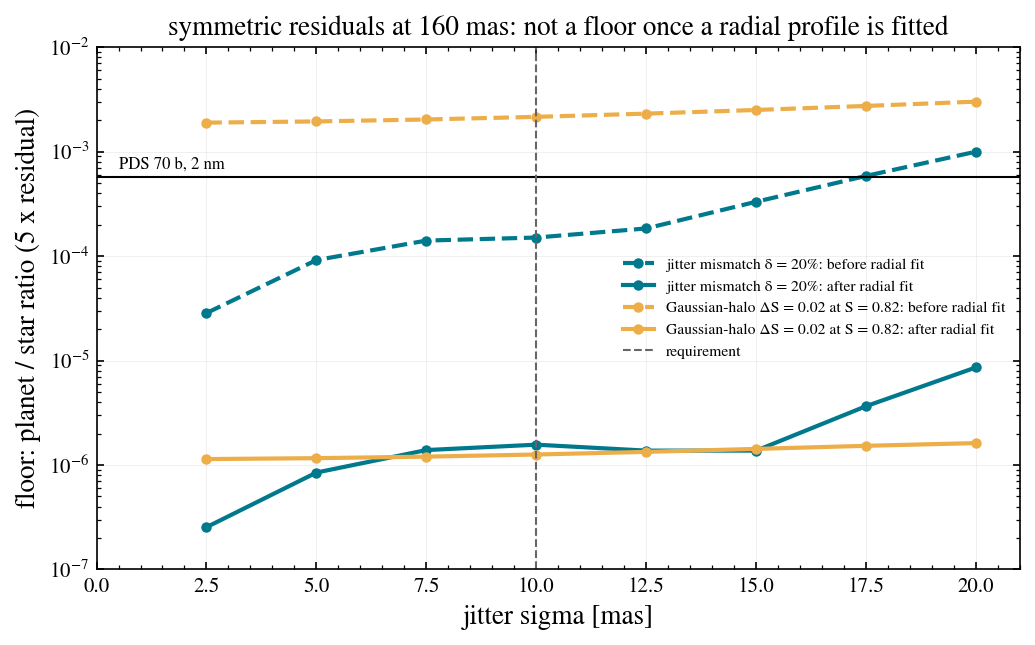

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.4))
jj = JITTERS[1:]
for name, mk, sc in [('jitter mismatch δ = 20%', lambda j: (inst.fine_psf(j), inst.fine_psf(1.2 * j)), TEAL),
                     ('Gaussian-halo ΔS = 0.02 at S = 0.82', lambda j: (inst.fine_psf(j, S_REQ), inst.fine_psf(j, S_REQ - 0.02)), AMBER)]:
    before = [speckle_floor(inst, *mk(j), [160.0], R_AP, radial_subtract=False)[0] for j in jj]
    after = [speckle_floor(inst, *mk(j), [160.0], R_AP, radial_subtract=True)[0] for j in jj]
    ax.plot(jj, before, 'o--', ms=4, color=sc, label=f'{name}: before radial fit')
    ax.plot(jj, after, 'o-', ms=4, color=sc, label=f'{name}: after radial fit')
ax.axhline(RB, color='k', lw=1); ax.text(0.5, RB * 1.2, 'PDS 70 b, 2 nm', fontsize=8)
req_lines(ax); ax.set_yscale('log'); ax.set_ylim(1e-7, 1e-2); ax.set_xlim(0, 21)
ax.set_xlabel('jitter sigma [mas]'); ax.set_ylabel('floor: planet / star ratio (5 x residual)')
ax.set_title('symmetric residuals at 160 mas: not a floor once a radial profile is fitted'); ax.legend(fontsize=7.5)
fig.tight_layout(); savefig(fig, 'fig09_js_symmetric_residuals')

### 3.2 Asymmetric residuals: wavefront drift and registration

**Wavefront drift.** The reference PSF has the same static wavefront as the science PSF plus a drift screen
of RMS $\delta$ [nm] in one of three spatial-frequency contents: *low-order* (focus + astigmatism, thermal
breathing), *mid-frequency* (flat spectrum at 3-5 cycles/D, which scatters light directly to 130-220 mas)
and *PSD-shaped* (same $f^{-2.5}$ spectrum as the static error, i.e. a small fractional change of the whole
pattern). The residual is first order in $\delta$: it is the interference of the drift speckles with the Airy
ring amplitude and with the static speckle pattern (speckle pinning), so the floor scales linearly with
$\delta$ and, for the low-order case, with the static wavefront error. Results are averaged over
`N_REAL` random realisations of the drift screen (and of the static screen where it matters).

**Registration.** The reference is shifted by $\Delta x$ mas relative to the science PSF; the residual is a
dipole on the Airy wing, first order in $\Delta x$.

drift-amplitude sweep in 107 s


all floors in 126 s



allowed drift [nm RMS] for the floor to equal PDS 70 b in the 2 nm band (5x margin), 160 mas, 10 mas jitter:
  S = 1.00: low-order 152.6 nm, mid-frequency 3-5 c/D 2.4 nm, PSD-shaped 3.6 nm
  S = 0.82: low-order 4.0 nm, mid-frequency 3-5 c/D 1.3 nm, PSD-shaped 1.8 nm
allowed registration error for the same: 3.27 mas


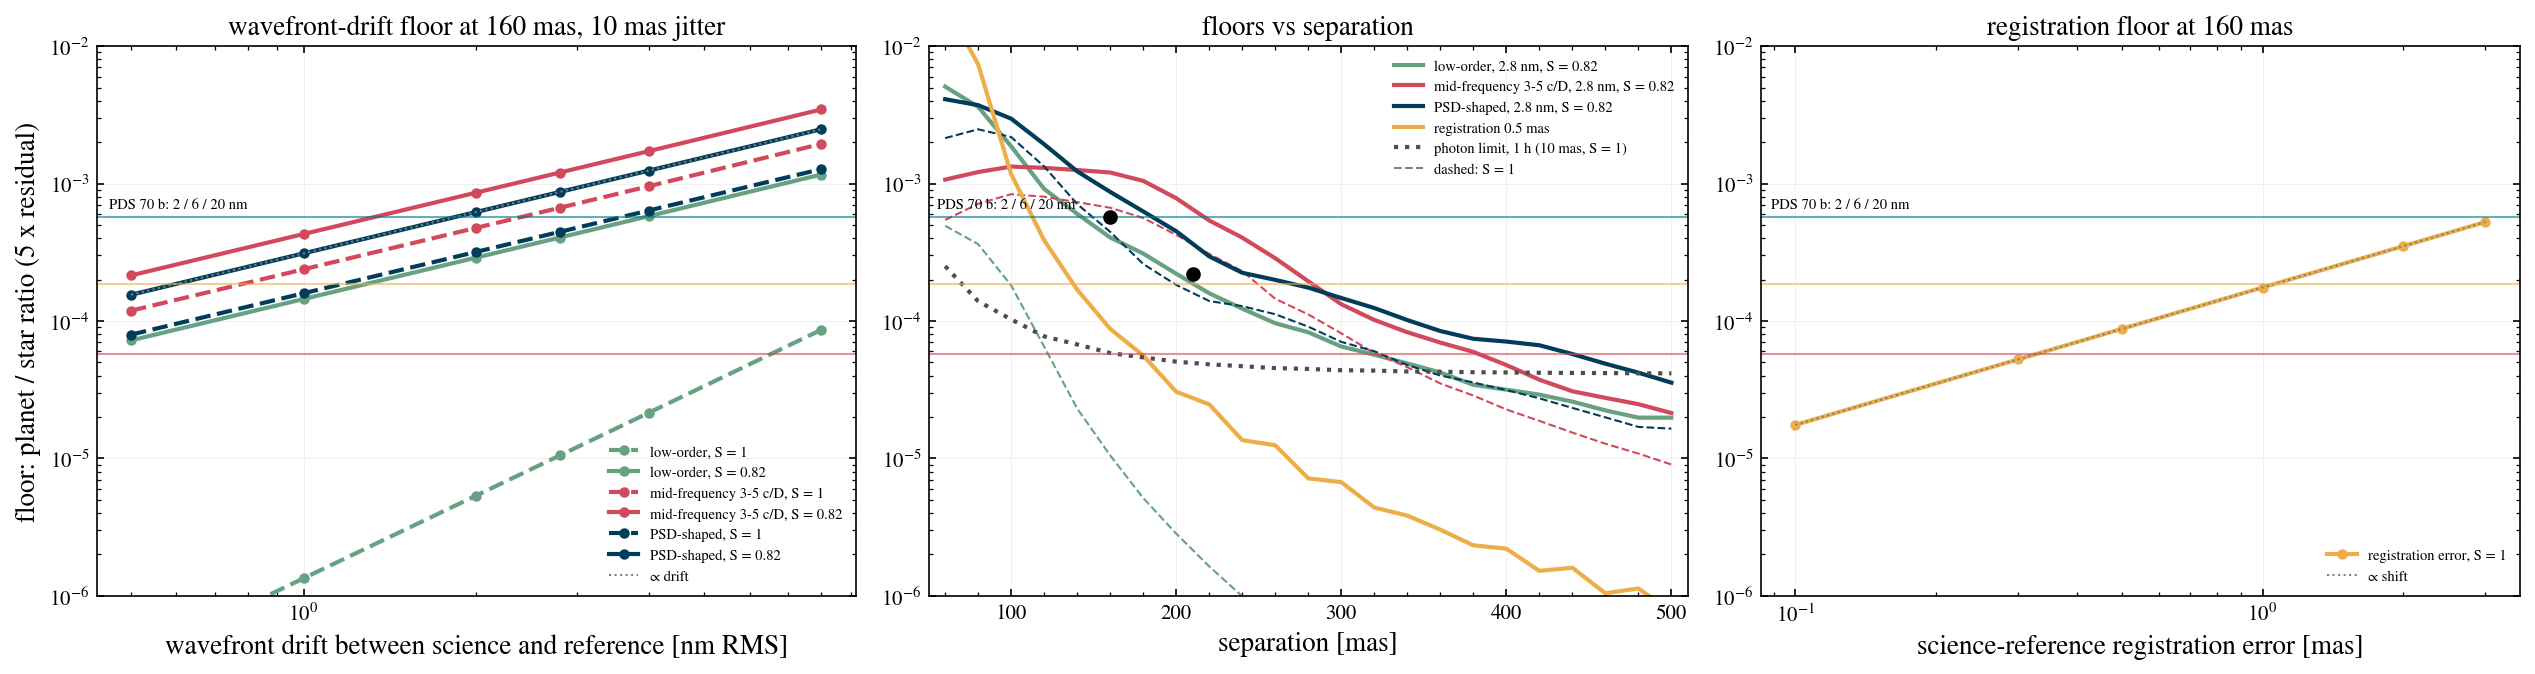

In [6]:
t0 = time.time()
DRIFTS = np.array([0.5, 1.0, 2.0, 2.8, 4.0, 8.0])
DTYPES = ['low-order', 'mid-frequency 3-5 c/D', 'PSD-shaped']
DCOL = dict(zip(DTYPES, [GREEN, RED, DBLUE]))

def drift_screen(w, kind, rms_nm):
    if kind == 'low-order':
        a = rms_nm / np.sqrt(2)
        return w.zernike_screen({'focus': a * w.rng.choice([-1, 1]), 'astig0': a * w.rng.choice([-1, 1])})
    if kind.startswith('mid'):
        return w.psd_screen(0.0, 3.0, 5.0, rms_nm)
    return w.psd_screen(2.5, 1.0, None, rms_nm)

def drift_floor(S, jitter, kind, rms_nm, seps, n_real=N_REAL):
    # mean over realisations of the static (if S<1) and drift screens
    out = np.zeros(len(seps))
    for r in range(n_real):
        w = WfePSF(inst, seed=100 * r + 1)
        stat = FLAT if S >= 1 else w.screen_for_strehl(float(S))
        p_sci = w.psf(stat, jitter)
        p_ref = w.psf(stat + drift_screen(w, kind, rms_nm), jitter)
        out += speckle_floor(inst, p_sci, p_ref, seps, R_AP)
    return out / n_real

# (a) floor vs drift amplitude at 160 mas, S = 1 and S = 0.82, 10 mas
FD = {}
for S in [1.0, S_REQ]:
    for kind in DTYPES:
        FD[S, kind] = np.array([drift_floor(S, REQ_JIT, kind, d, [160.0])[0] for d in DRIFTS])
print(f'drift-amplitude sweep in {time.time() - t0:.0f} s')

# (b) floor vs separation at DRIFT_NM
SEPS = np.arange(60.0, 501.0, 20.0)
FS = {(S, kind): drift_floor(S, REQ_JIT, kind, DRIFT_NM, SEPS) for S in [1.0, S_REQ] for kind in DTYPES}

# (c) registration
SHIFTS = np.array([0.1, 0.3, 0.5, 1.0, 2.0, 3.0])
psf0 = inst.fine_psf(REQ_JIT)
REG = np.array([speckle_floor(inst, psf0, shifted(psf0, dx, inst), [160.0], R_AP)[0] for dx in SHIFTS])
REG_SEP = speckle_floor(inst, psf0, shifted(psf0, 0.5, inst), SEPS, R_AP)
print(f'all floors in {time.time() - t0:.0f} s')

rows = []
for (S, kind), v in FD.items():
    for d, f in zip(DRIFTS, v): rows.append(dict(term=kind, strehl=S, sep_mas=160.0, amplitude=d, unit='nm rms', floor=f))
for dx, f in zip(SHIFTS, REG): rows.append(dict(term='registration', strehl=1.0, sep_mas=160.0, amplitude=dx, unit='mas', floor=f))
FLOORS = Table(rows); FLOORS['floor'].format = '%.3e'
FLOORS.write(os.path.join(OUT, 'js_asymmetric_floors.ecsv'), format='ascii.ecsv', overwrite=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
for kind in DTYPES:
    ax.plot(DRIFTS, FD[1.0, kind], 'o--', ms=4, color=DCOL[kind], label=f'{kind}, S = 1')
    ax.plot(DRIFTS, FD[S_REQ, kind], 'o-', ms=4, color=DCOL[kind], label=f'{kind}, S = 0.82')
ax.plot(DRIFTS, FD[S_REQ, 'PSD-shaped'][3] * DRIFTS / DRIFT_NM, ':', color='0.5', lw=1, label='∝ drift')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('wavefront drift between science and reference [nm RMS]')
ax.set_ylabel('floor: planet / star ratio (5 x residual)'); ax.set_title('wavefront-drift floor at 160 mas, 10 mas jitter')
ax = axes[1]
for kind in DTYPES:
    ax.plot(SEPS, FS[S_REQ, kind], color=DCOL[kind], label=f'{kind}, {DRIFT_NM} nm, S = 0.82')
    ax.plot(SEPS, FS[1.0, kind], '--', color=DCOL[kind], lw=1)
ax.plot(SEPS, REG_SEP, color=AMBER, label='registration 0.5 mas')
ax.plot(SEPS, contrast_curve(inst, REQ_JIT, 1.0, SEPS, T_TOT)['contrast'], ':', color='0.3', label='photon limit, 1 h (10 mas, S = 1)')
ax.plot([], [], '--', color='0.5', lw=1, label='dashed: S = 1')
ax.set_yscale('log'); ax.set_xlim(50, 510); ax.set_xlabel('separation [mas]'); ax.set_title(f'floors vs separation')
ax = axes[2]
ax.plot(SHIFTS, REG, 'o-', ms=4, color=AMBER, label='registration error, S = 1')
ax.plot(SHIFTS, REG[2] * SHIFTS / 0.5, ':', color='0.5', lw=1, label='∝ shift')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('science-reference registration error [mas]'); ax.set_title('registration floor at 160 mas')
for ax in axes:
    ax.set_ylim(1e-6, 1e-2)
    for f, col in zip(FILTERS, [TEAL, AMBER, RED]):
        ax.axhline(RATIO[f, 'b'], color=col, lw=1, alpha=0.6)
    ax.text(ax.get_xlim()[0] * 1.05 if ax.get_xscale() == 'log' else 55, RATIO['zwo:halpha2', 'b'] * 1.15, 'PDS 70 b: 2 / 6 / 20 nm', fontsize=7)
    ax.legend(fontsize=7, loc='lower right' if ax is not axes[1] else 'upper right')
for name, pl in PLANETS.items():
    axes[1].plot(pl['sep_mas'], RATIO['zwo:halpha2', name], 'o', color='k', ms=6)
fig.tight_layout(); savefig(fig, 'fig10_js_asymmetric_floors')

print(f'\nallowed drift [nm RMS] for the floor to equal PDS 70 b in the 2 nm band (5x margin), 160 mas, 10 mas jitter:')
for S in [1.0, S_REQ]:
    print(f'  S = {S:.2f}: ' + ', '.join(f'{kind} {DRIFT_NM * RB / FD[S, kind][3]:.1f} nm' for kind in DTYPES))
print(f'allowed registration error for the same: {0.5 * RB / REG[2]:.2f} mas')

## 4. Putting it together at the planet: what limits PDS 70 b across the grid

For each (jitter, Strehl) the detectable line flux at 160 mas in 1 h is the largest of: the photon limit
(section 2), the PSD-shaped wavefront-drift floor at `DRIFT_NM` nm, and the registration floor at 0.5 mas,
converted to flux with the PDS 70 host in the 2 nm filter. The right panel gives the wavefront drift (PSD-shaped)
that would put the floor exactly at PDS 70 b's nominal flux: the number to hold the PSF stability
requirement against. Jitter enters the drift floor only through the blur of the speckles.

drift grid in 71 s


corner cases at 160 mas (2 nm filter, PDS 70 host, 1 h); fluxes in erg/s/cm^2:
 jitter     S     photon  drift 2.8nm  reg 0.5mas  limit/F_b  allowed drift nm
    0.0  1.00   7.53e-17     5.67e-16    1.30e-16       0.70               4.0
   10.0  1.00   8.26e-17     5.84e-16    1.24e-16       0.72               3.9
   10.0  0.82   1.26e-16     1.18e-15    1.24e-16       1.46               1.9
   20.0  1.00   1.02e-16     7.10e-16    1.94e-16       0.88               3.2
   20.0  0.82   1.61e-16     1.35e-15    1.94e-16       1.66               1.7
   20.0  0.70   2.07e-16     1.83e-15    1.94e-16       2.26               1.2


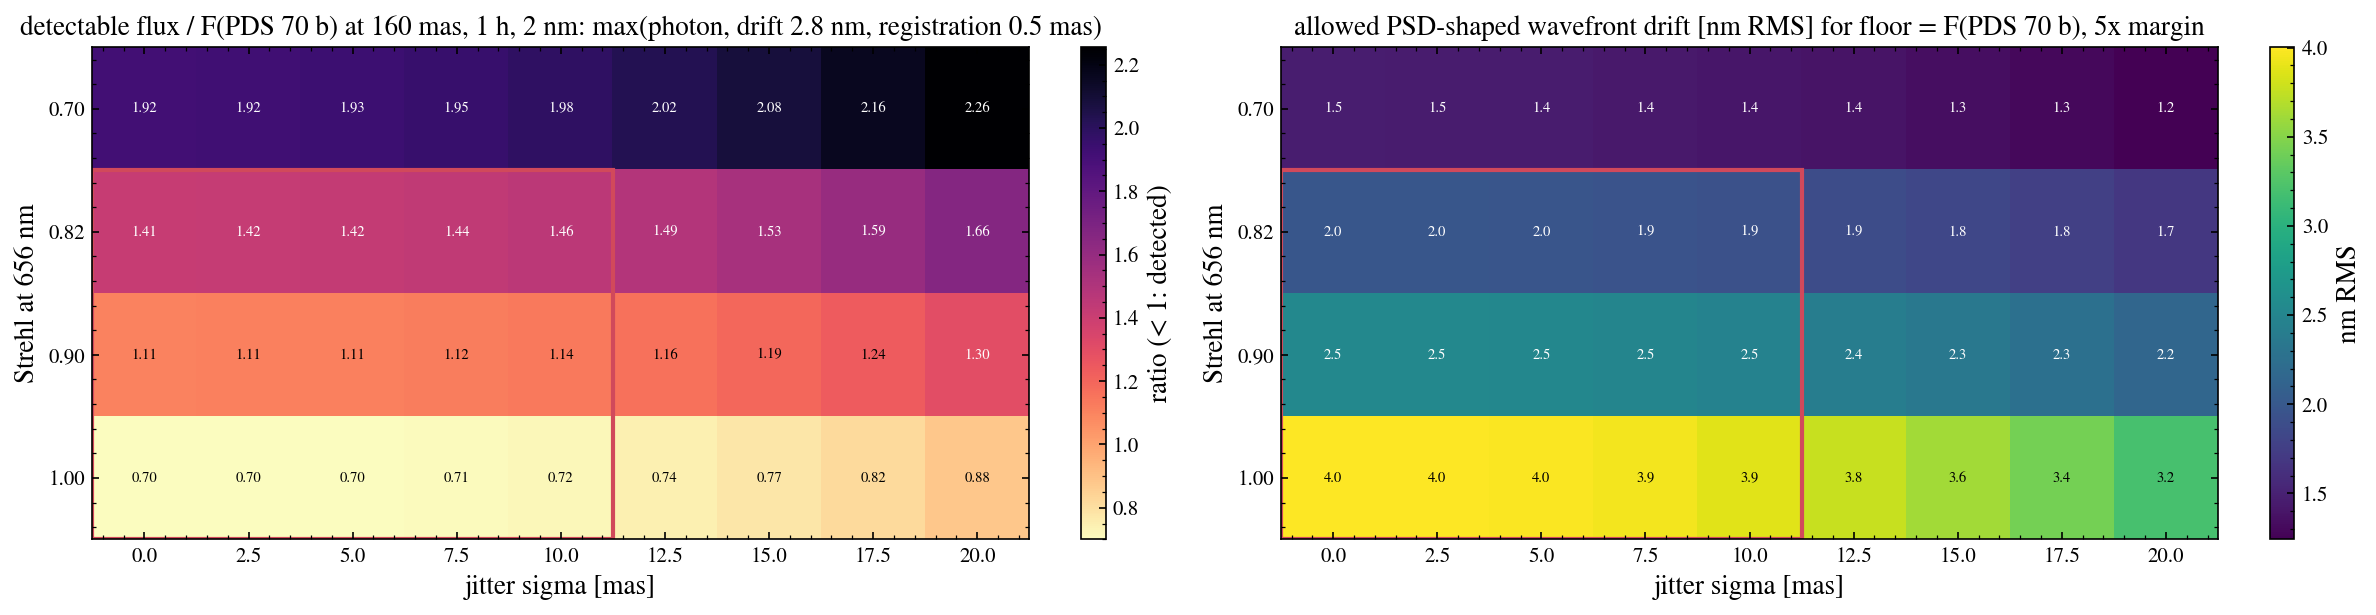

In [7]:
t0 = time.time()
DRIFT_GRID = np.empty((JITTERS.size, STREHLS.size))
for i, j in enumerate(JITTERS):
    for k, s in enumerate(STREHLS):
        DRIFT_GRID[i, k] = drift_floor(float(s), j, 'PSD-shaped', DRIFT_NM, [160.0], n_real=2)[0]
print(f'drift grid in {time.time() - t0:.0f} s')
REG05 = np.array([[speckle_floor(inst, inst.fine_psf(j), shifted(inst.fine_psf(j), 0.5, inst), [160.0], R_AP)[0] for s in STREHLS] for j in JITTERS])

m = 1
photon = LIM[:, :, m]
flo_d = DRIFT_GRID / per_1e16 * 1e-16
flo_r = REG05 / per_1e16 * 1e-16
worst = np.maximum.reduce([photon, flo_d, flo_r])
allowed = DRIFT_NM * RB / DRIFT_GRID
Table({'jitter': np.repeat(JITTERS, STREHLS.size), 'strehl': np.tile(STREHLS, JITTERS.size),
       'photon_lim': photon.ravel(), 'drift_floor_2p8nm': flo_d.ravel(), 'reg_floor_0p5mas': flo_r.ravel(),
       'allowed_drift_nm': allowed.ravel()}).write(os.path.join(OUT, 'js_combined_160mas.ecsv'), format='ascii.ecsv', overwrite=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
heatmap(axes[0], worst / PLANETS['b']['flux'], f'detectable flux / F(PDS 70 b) at 160 mas, 1 h, 2 nm: max(photon, drift {DRIFT_NM} nm, registration 0.5 mas)',
        cbar_label='ratio (< 1: detected)')
heatmap(axes[1], allowed, 'allowed PSD-shaped wavefront drift [nm RMS] for floor = F(PDS 70 b), 5x margin', fmt='{:.1f}', cmap='viridis',
        cbar_label='nm RMS')
fig.tight_layout(); savefig(fig, 'fig12_js_combined')

print('corner cases at 160 mas (2 nm filter, PDS 70 host, 1 h); fluxes in erg/s/cm^2:')
print(f"{'jitter':>7s} {'S':>5s} {'photon':>10s} {'drift 2.8nm':>12s} {'reg 0.5mas':>11s} {'limit/F_b':>10s} {'allowed drift nm':>17s}")
for j, s in [(0.0, 1.0), (10.0, 1.0), (10.0, STREHLS[iSR]), (20.0, 1.0), (20.0, STREHLS[iSR]), (20.0, 0.7)]:
    i = int(np.flatnonzero(JITTERS == j)[0]); k = int(np.argmin(np.abs(STREHLS - s)))
    print(f'{j:7.1f} {s:5.2f} {photon[i, k]:10.2e} {flo_d[i, k]:12.2e} {flo_r[i, k]:11.2e} {worst[i, k] / PLANETS["b"]["flux"]:10.2f} {allowed[i, k]:17.1f}')

## 5. Summary

* **Static PSF changes are a modest effect.** Across jitter 0-20 mas and Strehl 1.0-0.7 the photon-noise
  limit at 160 mas moves by a factor 0.9-2.5 (section 2, heatmap): the Airy wing is already the dominant
  light there and jitter only redistributes it between the rings. The Gaussian-halo model used for that grid
  is conservative: a power-law wavefront of the same Strehl puts less light at 160 mas at $S = 0.82$ (table in
  section 1). Lower Strehl and higher jitter also lower the peak and so lengthen the frames, which partly
  compensates in the read-noise term. At the requirement corner the photon limit for PDS 70 b is still
  several times below its flux in 1 h.
* **Jitter mismatch and symmetric halo changes are not the floor.** Their residuals are azimuthally
  symmetric and a radial-profile fit removes them to two orders of magnitude below the planets
  (section 3.1). Jitter matters for this science only through the static blur.
* **Wavefront stability between science and reference is the floor, and the number that matters is in nm,
  not in Strehl.** A drift of a few nm RMS produces speckles that interfere with the Airy rings (even at
  $S = 1$) and with the static aberration pattern, are not symmetric, and survive a radial fit. The floor
  is linear in the drift amplitude. The printed "allowed drift" values give the wavefront repeatability at
  which the floor (with a 5x bias margin) equals PDS 70 b's flux in the 2 nm band; mid-spatial-frequency
  content (3-5 cycles/D) is the most damaging per nm because it lands directly at the planets' separations,
  low-order drift matters only through the static aberrations it beats against.
* **Registration** between science and reference is a first-order dipole residual: 3 mas (0.2 px) puts
  the floor at PDS 70 b's flux (5x margin), 0.5 mas keeps it a factor 6 below. Sub-mas registration of a
  7-10 s frame on a G = 11.6 star is routine (centroid precision ~0.1 mas), so this is a pipeline
  requirement rather than a spacecraft one.
* **Filter.** All floors are ratios of the stellar light, so the 2 nm filter beats 20 nm by the full
  factor 10 here. That, more than the photon limit, is the reason to prefer it.
* **What to ask engineering for:** (i) wavefront repeatability between science and reference sequences at
  the level of the printed allowed drift, stated per spatial-frequency band, or equivalently the ability to
  observe a reference in the same thermal state or to roll the spacecraft for angular differential imaging;
  (ii) a bound on near-core scattered light inside 1", which no current model provides.

**Caveats.** Single-parameter floors with a coherent 5x margin (divide by 5 for the raw residual); real
residuals combine several terms and are partly averaged by roll or by many references. Wavefront screens
are random realisations (mean of `N_REAL`), unobscured pupil as in the ETC's Airy, monochromatic, static
within a sequence. A reference-scaling error (a few tenths of a percent from detector nonlinearity or host
variability) adds a symmetric term of 5·ε·(stellar aperture fraction)/EE, ~7e-5 per 1% at 160 mas before an
annulus fit removes it. Photometric scaling and radial-profile fitting are assumed; a planet-aware
pipeline (e.g. forward-modelled KLIP) may do better than the residual metric here suggests.